# 2_MLP_Backprop.ipynb

This notebook implements a **Multilayer Perceptron (MLP)** for facial emotion recognition using your local dataset.  
It trains using **backpropagation** and saves the model for later comparison.

**Classes:** Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
# Dataset path
data_dir = r"F:\TERM 7\CSM422 (DEEP LEARNING)\Emotion_recognitition\notebooks\dataset"
img_size = (48, 48)

In [3]:
images, labels = [], []
classes = sorted(os.listdir(data_dir))
for category in classes:
    folder = os.path.join(data_dir, category)
    if not os.path.isdir(folder): continue
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = load_img(path, target_size=img_size)
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
            labels.append(category)
        except Exception as e:
            continue
X, y = np.array(images), np.array(labels)
print(f"Loaded {len(X)} images.")

Loaded 3589 images.


In [4]:
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 2871, Test: 718


In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print("Flattened shape:", X_train_flat.shape)

Flattened shape: (2871, 6912)


In [6]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(y_encoded.shape[1], activation='softmax')
])
model.summary()

C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       3,539,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,704,583 (14.13 MB)

 Trainable params: 3,704,583 (14.13 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train_flat, y_train, validation_data=(X_test_flat, y_test),
                    epochs=30, batch_size=64, callbacks=[early_stop], verbose=1)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.1930 - loss: 2.4795 - val_accuracy: 0.2326 - val_loss: 1.8430
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.2173 - loss: 1.8713 - val_accuracy: 0.2604 - val_loss: 1.8343
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.2365 - loss: 1.8426 - val_accuracy: 0.2507 - val_loss: 1.8226
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.2348 - loss: 1.8496 - val_accuracy: 0.2493 - val_loss: 1.8159
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.2508 - loss: 1.8214 - val_accuracy: 0.2646 - val_loss: 1.8124
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.2407 - loss: 1.8294 - val_accuracy: 0.2493 - val_loss: 1.8133
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.2490 - loss: 1.8078 - val_accuracy: 0.2493 - val_loss: 1.8081
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.2476 - loss: 1.8094 - val_accuracy: 0.2493 - v

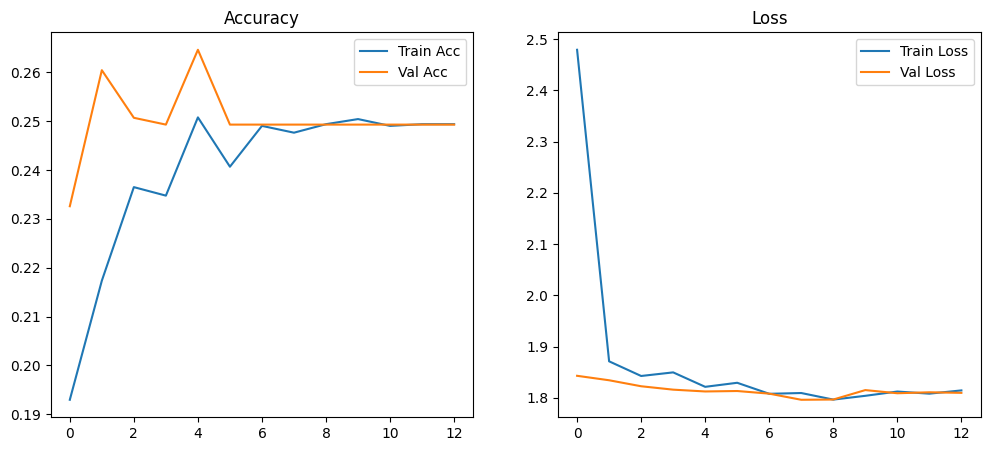

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step 
              precision    recall  f1-score   support

       Angry       0.00      0.00      0.00        93
     Disgust       0.00      0.00      0.00        11
        Fear       0.00      0.00      0.00        99
       Happy       0.25      1.00      0.40       179
     Neutral       0.00      0.00      0.00       122
         Sad       0.00      0.00      0.00       131
    Surprise       0.00      0.00      0.00        83

    accuracy                           0.25       718
   macro avg       0.04      0.14      0.06       718
weighted avg       0.06      0.25      0.10       718



C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kumar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificati

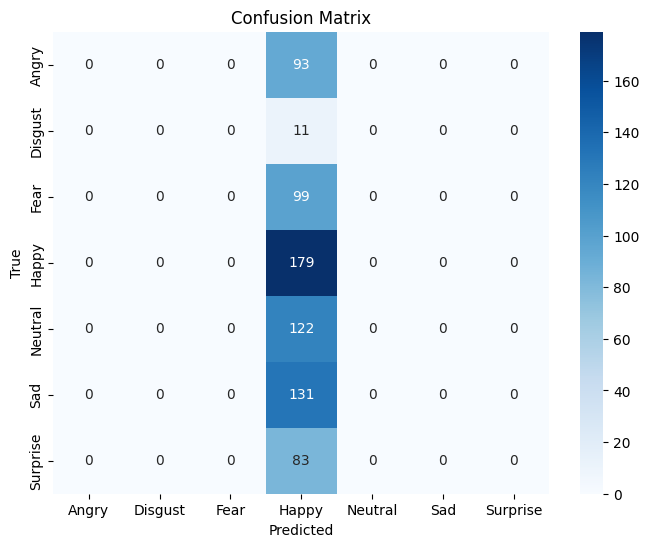

In [9]:
y_pred = model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
print(classification_report(y_true, y_pred_classes, target_names=lb.classes_))
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

In [10]:
model.save("mlp_model.h5")
print("Model saved as mlp_model.h5")

Model saved as mlp_model.h5


## ✅ Summary
- Loaded and preprocessed local dataset  
- Split 80/20 for train-test  
- Trained an MLP with backpropagation  
- Evaluated model performance  
- Saved the model for later comparison  
Next: **3_CNN_Image_Emotion.ipynb**